# IGR Workshop 2: Field Hillslope Profile Processing
Sim M. Reaney, IGR, 2026.  
During your fieldwork at Langdon beck, you collected data for a number of hillslope profiles using both teh handheld GPS units and the distance-angle approach. This workshop focuses on processing these hillslope profile data using Python. We will cover data loading, cleaning, analysis, and visualisation techniques. By the end of this workshop, you will be able to:
1. Load and process hillslope profile data.
2. Visualise hillslope profiles using matplotlib.
3. Perform statistical analysis on hillslope profile data to compare it with other data sources.

## Workshop Outline
### 1. Reading in a survey of a field hillslope profile
- Reading a csv file into a pandas DataFrame.
- Understanding the structure of hillslope profile data.
- Processing the distances and angles into a distance-elevation format.
### 2. Visulaisation of the hillslope profile
- Plotting the hillslope profile using matplotlib.
- Customising the plot with labels, titles, and legends.
<!-- - Saving the visualisation to a file. -->
### 3. Creating profile from GPS points and the LiDAR DEM
- Loading the LiDAR DEM data.
- Sampling elevation data from the DEM based on GPS points.
- Comparing the GPS-derived profile with the LiDAR-derived profile.
### 4. Statistical Analysis
- Calculating the strength of the relationship between the two profiles using linear regression.
### 5. Cleaning and importng your own data
- Guidelines for cleaning hillslope profile data.
- Importing and processing your own hillslope profile data.
  

## Reading in the data. 
The first step is to read in the hillslope profile data collected in the field. This data is stored in a CSV file format. We will use the pandas library to read the data into a Pandas DataFrame for easier manipulation and analysis. The CSV file contains columns for distance, angle, and elevation measurements taken along the hillslope profile from both teh distance-angle methods and from the GPS. We need to read in a sample profile here to develop the code and later in the workshop, you will apply this to your own data. The fist part of this block needs to import the pandas library: 

```
import pandas as pd
```

Next, we read in the CSV file using the `pd.read_csv()` function. Make sure to provide the correct path to your CSV file. Here is an example code snippet to read in the data:

```python
# Read in the hillslope profile data
df = pd.read_csv('https://simreaney.github.io/IGR/WS02/survey.csv') 
```
Once the data is read in, we can take a look at the first few rows of the DataFrame to understand its structure:

```python
# Display the first few rows of the DataFrame
print(df.head())
```     
This will give you an overview of the data and help you identify the columns that contain the distance, angle, and elevation measurements. You can then proceed to process this data for further analysis and visualisation.    

In [42]:
# import numpy as np

import pandas as pd

# df = pd.read_csv('survey.csv')
df = pd.read_csv('https://simreaney.github.io/IGR/WS02/survey.csv') 

print(df.head())

   surveyDistance  surveyAngle  GPS_x  GPS_y  GPS_alt
0             0.0          0.0  85125  33923      483
1             5.0         -2.5  85128  33918      481
2             7.0         -4.5  85129  33911      482
3             7.0         -4.0  85132  33904      481
4             5.0         -6.0  85135  33899      482


## Processing the distance-angle data and visualising the hillslope profile
To process the distance-angle data into a distance-elevation format, we need to convert the angles into elevation changes. We can use trigonometric functions to calculate the elevation at each point along the hillslope profile. Teh fist step is to import the numpy library fror the tig functions and matplotlib for plotting:   

```python
import numpy as np
import matplotlib.pyplot as plt    
 ```

Next we need to extend the dataframe to include the distance and altitudes from the survey. We do this with the following two commands. These command create two new columns in the dataframe and initialise them to zero. 

```python  
df['distanceSurvey'] = 0.0
df['altSurvey'] = 0.0
```

If you run df.head() again, you will see the new columns added to the dataframe. Now we can calculate the elevation changes and cumulative elevation using the distance and angle data. Before starting the calculations, you need to set a starting altitude for the profile. This is done with the following line of code which takes the first GPS altitude measurement as the starting point.

```python  
startAlt = df['GPS_alt'].iloc[0]
```
Now you can proceess through the field data to process the distance-angle data into distance-elevation format. The following code  does these calcualtions:

* To do this calculation you need to use a for loop that works it way though each of the field measirements. This is set up with the for i in range(0, len(df)) line. The len(df) gives you the length (number of rows) of field data that were imported. 
* Inside the for loop, you need to convert the survey angle from degrees to radians using the np.deg2rad() function. This is necessary because the trigonometric functions in Python and numpy use radians.
* Next, calculate the change in altitude (altChange) using the tangent of the angle multiplied by the survey distance.
* Then, update the cumulative distance and altitude for each point in the DataFrame. For the first point (i == 0), set the distance and altitude directly. For subsequent points, add the current distance and altitude changes to the previous values.
* You can use the .at[] method to update specific cells in the DataFrame. The first argument is the row index, and the second argument is the column name and then after the = sign you put the value you want to assign to that cell.

```python  
for i in range(0, len(df)):
    angleRad = np.deg2rad(df["surveyAngle"].iloc[i])
    altChange = df["surveyDistance"].iloc[i] * np.tan(angleRad)
    
    if i == 0:
        df.at[i, "distanceSurvey"] = df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = startAlt + altChange
    else:
        df.at[i, "distanceSurvey"] = df.at[i-1, "distanceSurvey"] + df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = df.at[i-1, "altSurvey"] + altChange
```

Again, you can use df.head() to check that the new columns have been populated correctly.
```python  
print(df.head())
```

In [43]:
import matplotlib.pyplot as plt
import numpy as np

df['distanceSurvey'] = 0.0
df['altSurvey'] = 0.0

startAlt = df['GPS_alt'].iloc[0]

for i in range(0, len(df)):
    angleRad = np.deg2rad(df["surveyAngle"].iloc[i])
    altChange = df["surveyDistance"].iloc[i] * np.tan(angleRad)
    
    if i == 0:
        df.at[i, "distanceSurvey"] = df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = startAlt + altChange
    else:
        df.at[i, "distanceSurvey"] = df.at[i-1, "distanceSurvey"] + df["surveyDistance"].iloc[i]
        df.at[i, "altSurvey"] = df.at[i-1, "altSurvey"] + altChange

print(df.head())

   surveyDistance  surveyAngle  GPS_x  GPS_y  GPS_alt  distanceSurvey  \
0             0.0          0.0  85125  33923      483             0.0   
1             5.0         -2.5  85128  33918      481             5.0   
2             7.0         -4.5  85129  33911      482            12.0   
3             7.0         -4.0  85132  33904      481            19.0   
4             5.0         -6.0  85135  33899      482            24.0   

    altSurvey  
0  483.000000  
1  482.781695  
2  482.230783  
3  481.741296  
4  481.215774  


### Visulaising the hillslope profile
You can now visualise the processed hillslope profile using matplotlib. The following code snippet creates a simple line plot of altitude versus distance along the hillslope profile. 
```python
# Plot the hillslope profile
plt.figure(figsize=(12, 5))
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o', label='Survey')
plt.xlabel('Distance (m)')
plt.ylabel('Altitude (m)')
plt.legend()
plt.grid(True)
plt.show()
```
The new aspects from last week are the addation of 
* The plt.grid(True) that adds a grid to the plot to help with the interpreation of the profile.
* The marker='o' argument to the plt.plot() function which adds circular markers at each data point along the profile. This makes it easier to see the individual measurements taken in the field. You can change the marker style by using different characters, such as 's' for squares or '^' for triangles.
* The label='Survey' argument to the plt.plot() function which adds a label to the line in the plot. This is useful when you have multiple lines on the same plot and want to distinguish between them. 
* You add a legend to the plot by including the plt.legend() function after plotting all the lines.

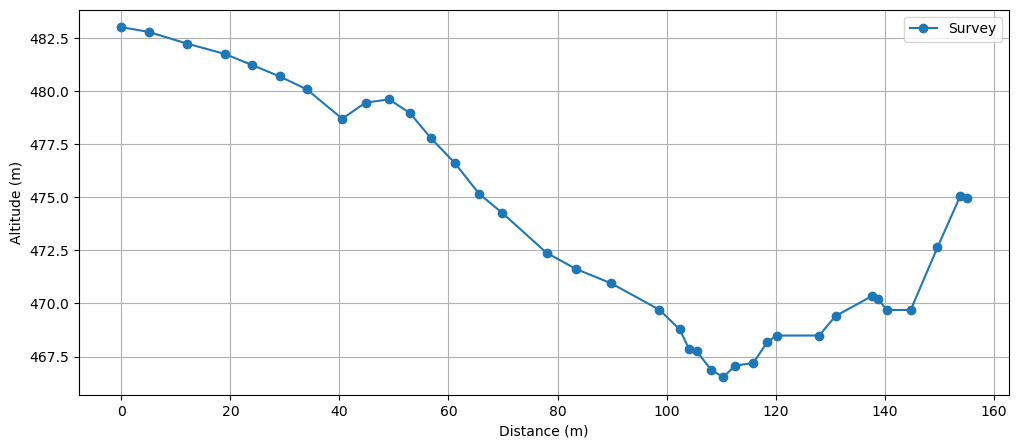

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o', label='Survey')
plt.xlabel('Distance (m)')
plt.ylabel('Altitude (m)')
plt.legend()
plt.grid(True)
plt.show()

3. Creating profile from GPS points
In the field, you also collected GPS points along the hillslope profile. You can use these GPS points to create a profile and compare it with the distance-angle derived profile. The GPS data is already included in the DataFrame under the as the x, y and altitude. These columns need to be converted into the distances along the profile. To do this calcualtion, we need to take the x and y differences between the pairs of points and then use Pythagoras theorem to calculate the distance. However, the GPS readings have been stored as the values within the NY Ordinance Survey grid system and hence to map correctly into space, we need to add the offset of the start of the this square to the recorded values. Do do this, we add 300 km to the easting and 500 km to the northing. The following code does this calculation.

```python
df["GPS_x"] = df["GPS_x"] + 300000
df["GPS_y"] = df["GPS_y"] + 500000
``` 

Next, we need to create two new columns in the DataFrame to store the cumulative distance from the GPS data. We can initialise these columns to zero as before:

```python
df['distanceGPS'] = 0.0
```

Now we can process through the GPS data to calculate the cumulative distance along the profile. The following code does this calculation:

```python
for i in range(0, len(df)):
    if i == 0:
        df.at[i, "distanceGPS"] = 0.0
    else:
        deltaX = df["GPS_x"].iloc[i] - df["GPS_x"].iloc[i-1]
        deltaY = df["GPS_y"].iloc[i] - df["GPS_y"].iloc[i-1]
        distance = np.sqrt(deltaX**2 + deltaY**2)
        df.at[i, "distanceGPS"] = df.at[i-1, "distanceGPS"] + distance
``` 

You can now update the profile plot to include the GPS-derived profile. The following code snippet adds the GPS profile to the existing plot. You need to add this line after the .previous plt.plot line in the previous plotting code. You shoudl copy and paste your previous plotting code and just add this new line to it.

```python
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
```

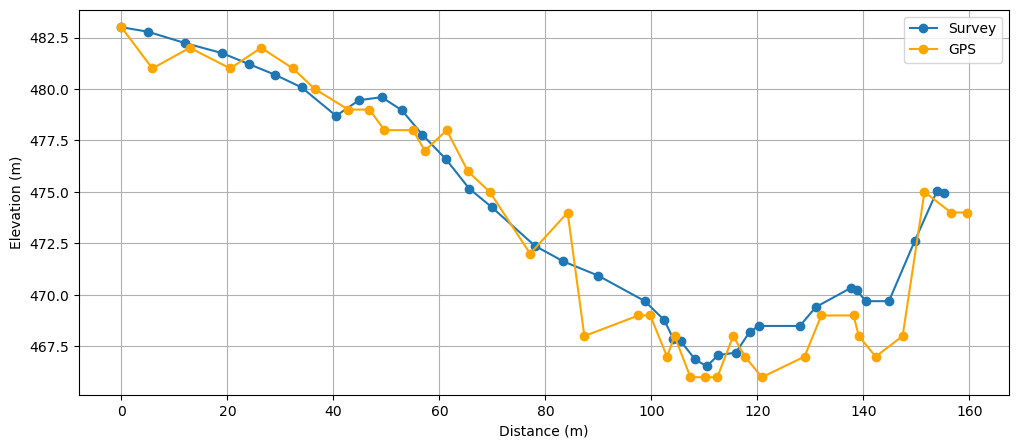

In [45]:


df["GPS_x"] = df["GPS_x"] + 300000
df["GPS_y"] = df["GPS_y"] + 500000

df['distanceGPS'] = 0.0

for i in range(len(df)):
    if i == 0:
        # distanceGPS[i] = 0
        df.at[i, "distanceGPS"] = 0.0
    else:
        delta_easting = df.at[i, "GPS_x"] - df.at[i-1, "GPS_x"] 
        delta_northing = df.at[i, "GPS_y"] - df.at[i-1, "GPS_y"] 
        segment_distance = np.sqrt(delta_easting**2 + delta_northing**2)
        df.at[i, "distanceGPS"]  = df.at[i-1, "distanceGPS"]  + segment_distance

plt.figure(figsize=(12, 5))
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o',label='Survey')
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
# plt.plot(distanceSurvey, altSurvey, marker='o')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.grid(True)
plt.legend()
plt.show()




## Comparing the two profiles to the LiDAR DEM
To compare the GPS-derived profile with the LiDAR-derived profile, you need to load the LiDAR DEM data. This data is typically stored in a raster format, such as GeoTIFF. You can use the rasterio library to read the DEM data and sample elevation values based on the GPS points. First, you need to install the rasterio library if you haven't already:

Next, you can use the following code snippet to load the LiDAR DEM data and sample elevation values:
```python
import rasterio
from rasterio.plot import show

# Load the LiDAR DEM data
dem = rasterio.open('https://simreaney.github.io/IGR/WS02/Langdon_Beck.tif')
```

You can then visulaise the DEM data using the following code:
```python
plt.figure(figsize=(12, 5))
plt.title('DEM - Langdon Beck')
show(dem, cmap='terrain')
```

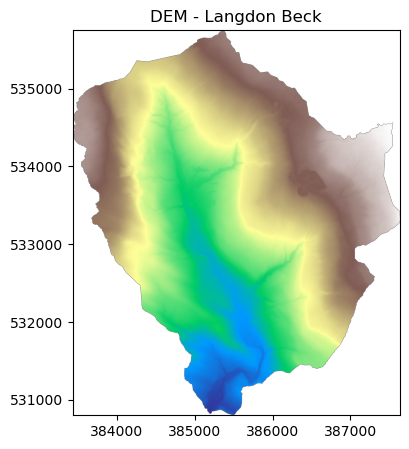

<Axes: title={'center': 'DEM - Langdon Beck'}>

In [46]:
# Read in LiDAR data
import rasterio
from rasterio.plot import show
dem = rasterio.open('https://simreaney.github.io/IGR/WS02/Langdon_Beck.tif')

plt.figure(figsize=(12, 5))
plt.title('DEM - Langdon Beck')
show(dem, cmap='terrain')


## Visulasing the profile on the LiDAR DEM
To visualise the GPS survey points on the DEM, we can generate a zoomed in plot of the DEM around the survey points and then overplot the GPS points on top. The code int he following block creates this visulisation. However, there are three errors in the code that you need to resolve. 

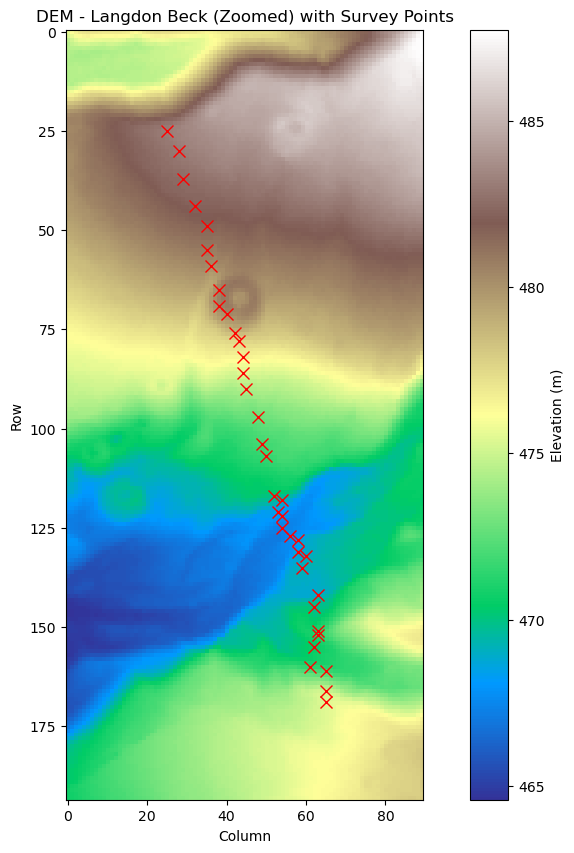

In [ ]:

# Calculate bounds of survey points with buffer
buffer = 25  # meters
min_easting = min(df['GPS_x']) - buffer
max_easting = max(df['GPS_x']) + buffer
min_northing = min(df['GPS_y']) - buffer
max_northing = max(df['GPS_y']) + buffer

# Create list of (x, y) pairs for survey points
xy_pairs = list(zip(df['GPS_x'], df['GPS_y']))

# Convert to pixel coordinates
min_row, min_col = dem.index(min_easting, max_northing)
max_row, max_col = dem.index(max_easting, min_northing)

# Extract zoomed DEM
dem_array = dem.read(1)
dem_zoomed = dem_array[min_row:max_row, min_col:max_col]

# Plot zoomed DEM with survey points
plt.figure(figsize=(12, 10))
plt.imshow(dem_zoomed, cmap='terrain')
plt.colorbar(label='Elevation (m)')

# Overlay survey points
for x, y in xy_pairs:
    row, col = dem.index(x, y)
    plt.plot(col - min_col, row - min_row, 'rx', markersize=8)

plt.title('DEM - Langdon Beck (Zoomed) with Survey Points')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

## Get LiDAR elevations for the GPS points
To sample elevation values from the DEM based on the GPS points, you can use the following code snippet:
```python
# Sample elevation values from the DEM based on GPS points
gps_elevations = []
for i in range(len(df)):
    row, col = dem.index(df['GPS_x'].iloc[i], df['GPS_y'].iloc[i])
    elevation = dem.read(1)[row, col]
    gps_elevations.append(elevation)        
df['LiDAR_alt'] = gps_elevations
```
You can then update the profile plot to include the LiDAR-derived profile. The following code snippet adds the LiDAR profile to the existing plot. You need to add this line after the previous plt.plot lines in the previous plotting code. You shoudl copy and paste your previous plotting code and just add this new line to it.
```python
plt.plot(df['distanceGPS'], df['LiDAR_alt'], marker='o', color='red', label='LiDAR')
``` 
You can now see three different profiles of the same hillslope on the same plot: the distance-angle derived profile, the GPS-derived profile, and the LiDAR-derived profile. This allows you to visually compare the different methods of obtaining hillslope profiles. However, to quantify the relationship between the profiles, we can perform statistical analysis using linear regression.

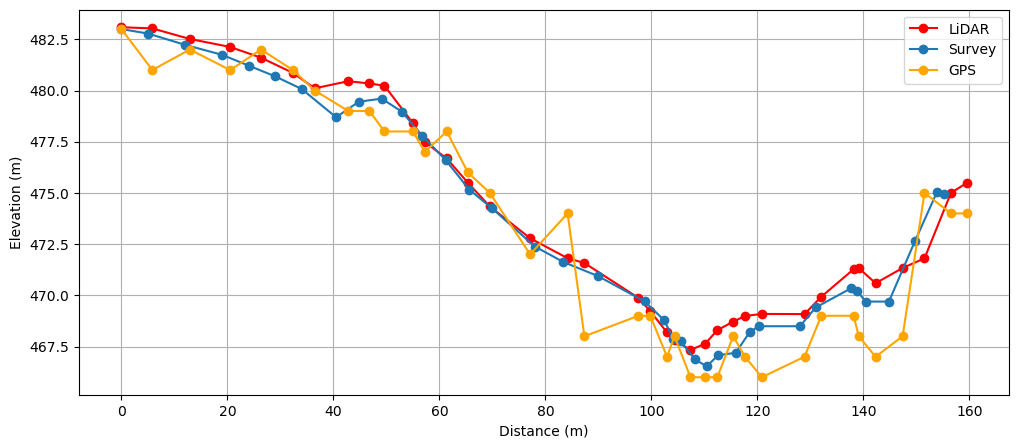

In [47]:

gps_elevations = []
for i in range(len(df)):
    row, col = dem.index(df['GPS_x'].iloc[i], df['GPS_y'].iloc[i])
    elevation = dem.read(1)[row, col]
    gps_elevations.append(elevation)        
df['elevationsDEM'] = gps_elevations

plt.figure(figsize=(12, 5))
plt.plot(df['distanceGPS'], df['elevationsDEM'], marker='o', color='red', label='LiDAR')
plt.plot(df["distanceSurvey"], df["altSurvey"], marker='o',label='Survey')
plt.plot(df['distanceGPS'], df['GPS_alt'], marker='o', color='orange', label='GPS')
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
plt.grid(True)
plt.legend()
plt.show()



## Comparing the two profiles using linear regression
To quantify the relationship between the GPS-derived profile and the LiDAR-derived profile, we can use linear regression. The scipy library provides a convenient function to perform linear regression analysis. You can use the following code snippet to perform linear regression and print the results:
```python
from scipy.stats import linregress  
# Perform linear regression between GPS-derived and LiDAR-derived profiles
slope, intercept, r_value, p_value, std_err = linregress(df['GPS_alt'], df['LiDAR_alt'])
print(f'R-squared: {r_value**2:.4f}')
```
The R-squared value indicates the strength of the relationship between the two profiles. A value close to 1 indicates a strong correlation, while a value close to 0 indicates a weak correlation.  


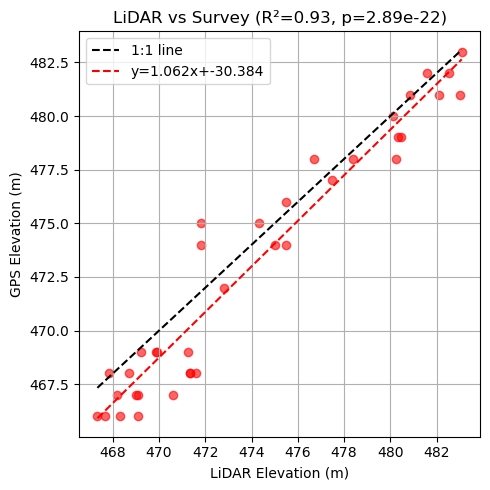

In [40]:
from scipy import stats

fig, axes = plt.subplots(figsize=(5, 5))

# Left plot: LiDAR vs GPS
axes.scatter(df['elevationsDEM'], df['GPS_alt'], alpha=0.6, color='red')
axes.plot([min(df['elevationsDEM']), max(df['elevationsDEM'])], [min(df['elevationsDEM']), max(df['elevationsDEM'])], 'k--', label='1:1 line')

slope, intercept, r_value, p_value, std_err = stats.linregress(df['elevationsDEM'], df['GPS_alt'])
line_x = np.array([df['elevationsDEM'].min(), df['elevationsDEM'].max()])
line_y = slope * line_x + intercept
axes.plot(line_x, line_y, 'r--', label=f'y={slope:.3f}x+{intercept:.3f}')

axes.set_xlabel('LiDAR Elevation (m)')
axes.set_ylabel('GPS Elevation (m)')
axes.set_title(f'LiDAR vs Survey (R²={r_value**2:.2f}, p={p_value:.2e})')
axes.grid(True)
axes.legend()
plt.tight_layout()
plt.show()

## Cleaning and importing your own data
When working with hillslope profile data, it is essential to ensure that the data is clean and free from errors. Here are some guidelines for cleaning hillslope profile data:
1. Check for missing values and handle them appropriately (e.g., interpolation, removal).
2. Identify and remove outliers that may skew the analysis.
3. Ensure that the distance and angle measurements are in the correct units (e.g., meters, degrees).
4. Verify that the GPS coordinates are accurate and correspond to the correct locations along the hillslope profile.
Once your data is cleaned, you can import and process your own hillslope profile data using the techniques covered in this workshop. Simply replace the sample CSV file path with the path to your own data file when reading in the data using pandas. Follow the same steps for processing, visualisation, and analysis as demonstrated in this workshop.

----
Sim M. Reaney, IGR, 2026.
https://simreaney.github.io/